<a href="https://colab.research.google.com/github/Dima-BR/machine-learning-projects/blob/main/Heart_Failure_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heart Failure Prediction

# Import Library & Download The Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
import os


In [ ]:
# 1. Download the dataset
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

# 2. Construct the full path to the specific CSV file
file_path = os.path.join(path, "heart.csv")

# 3. Load the data into a DataFrame
df = pd.read_csv(file_path)

Using Colab cache for faster access to the 'heart-failure-prediction' dataset.


In [ ]:
# Ensuring you use the correct filename
print(os.listdir(path))


['heart.csv']


# Exploring Data

In [ ]:
df.head()


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
df.shape

(918, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


In [ ]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


<Axes: >

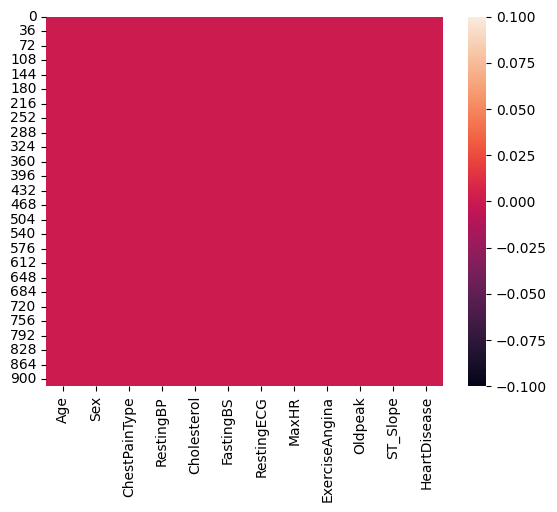

In [ ]:
sns.heatmap(df.isnull())

In [ ]:
df.duplicated().sum()

np.int64(0)

## Conclusion


The shape of the data (918, 12)

there is no duplicate and there is no null value / missing values in the dataset

***Features:***
 'Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS','RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope'

***Target:***
  HeartDisease >> binary (0 for no disease, 1 for disease)

  Numerical Features:
  Age, RestingBP, Cholesterol, FastingBS, MaxHR, Oldpeak
  - These are ready for mathematical operations and statistical modeling

  Categorical Features:
  Sex, ChestPainType, RestingECG, ExerciseAngina, ST_Slope are stored as object
  - Since machine learning models generally require numerical input, We need to perform encoding (like One-Hot Encoding or Label Encoding) on these columns before training a model.



> We are looking at a Binary Classification problem depend on HeartDisease(Target-Y)



# Analysis

In [ ]:
df['HeartDisease'].value_counts()

,count
HeartDisease,
1,508
0,410


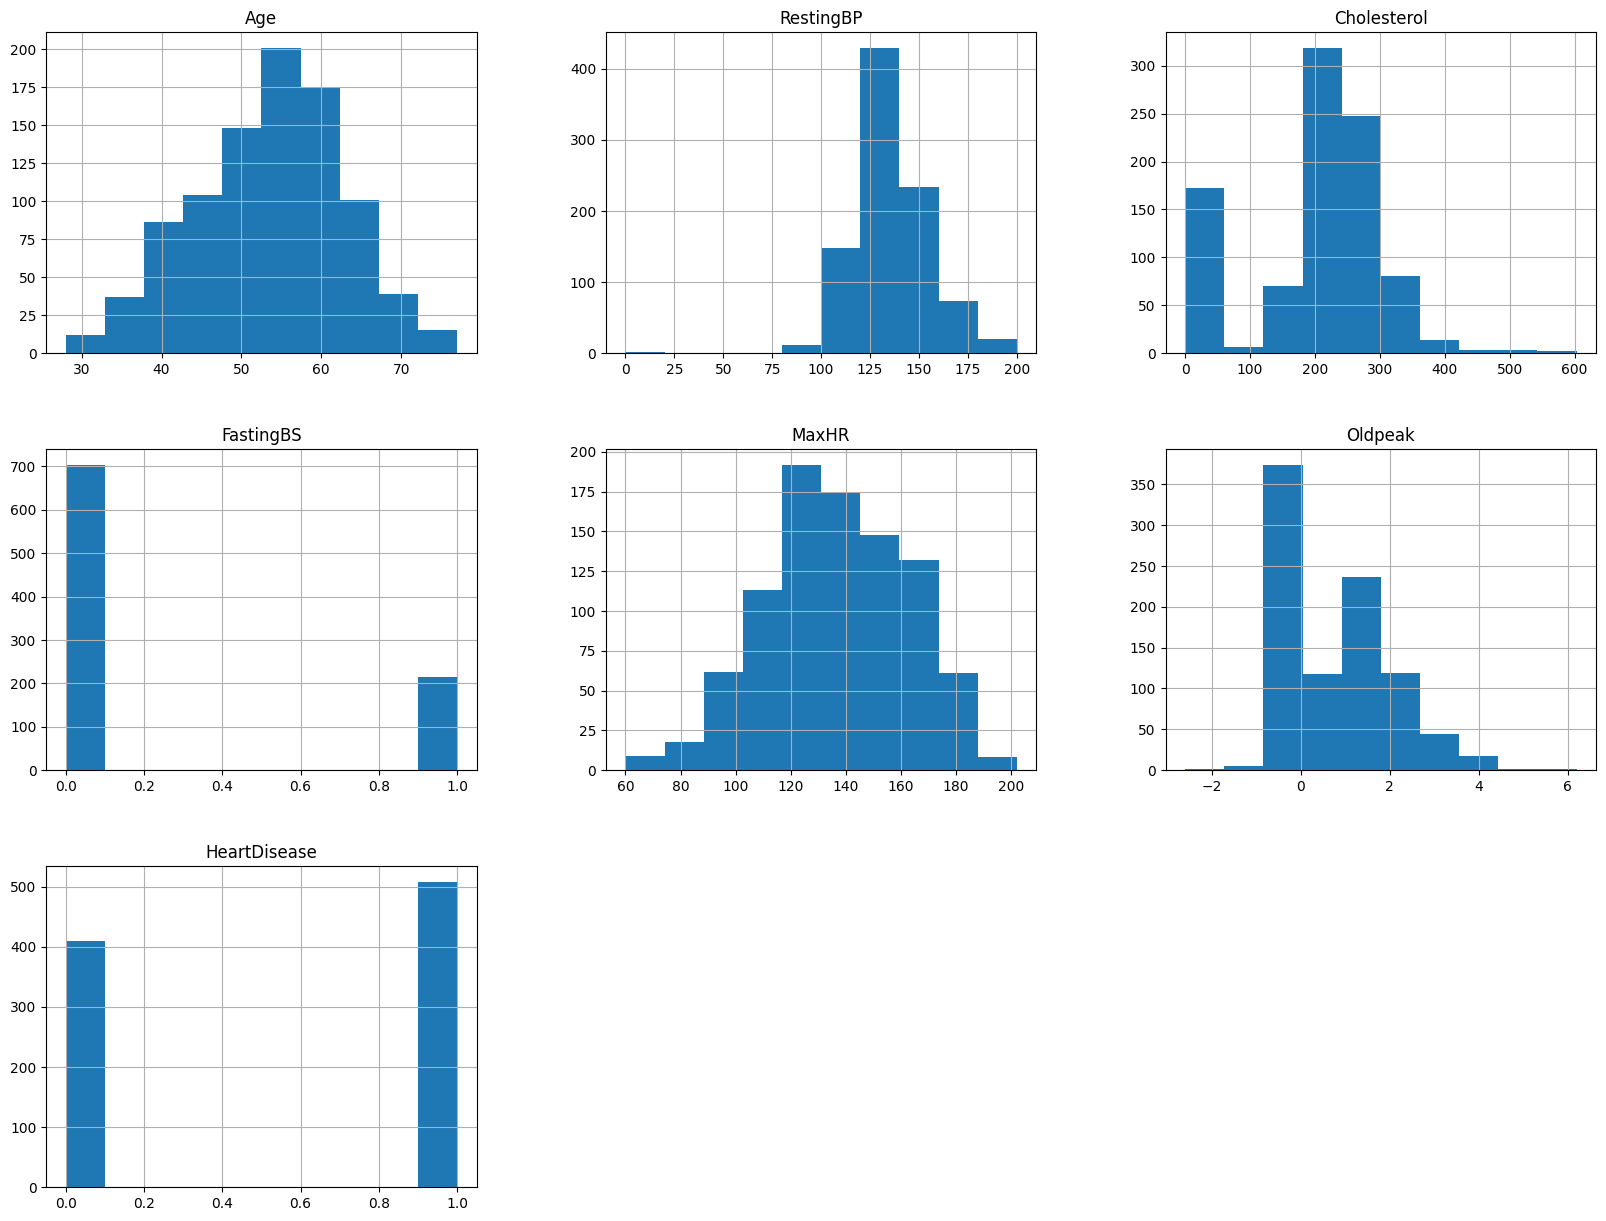

In [ ]:
df.hist(figsize=(20, 15))
plt.show()

In [ ]:
numurical_df= df[[ 'Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']]

In [ ]:
numurical_df.head(10)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
0,40,140,289,0,172,0.0,0
1,49,160,180,0,156,1.0,1
2,37,130,283,0,98,0.0,0
3,48,138,214,0,108,1.5,1
4,54,150,195,0,122,0.0,0
5,39,120,339,0,170,0.0,0
6,45,130,237,0,170,0.0,0
7,54,110,208,0,142,0.0,0
8,37,140,207,0,130,1.5,1
9,48,120,284,0,120,0.0,0


<Axes: >

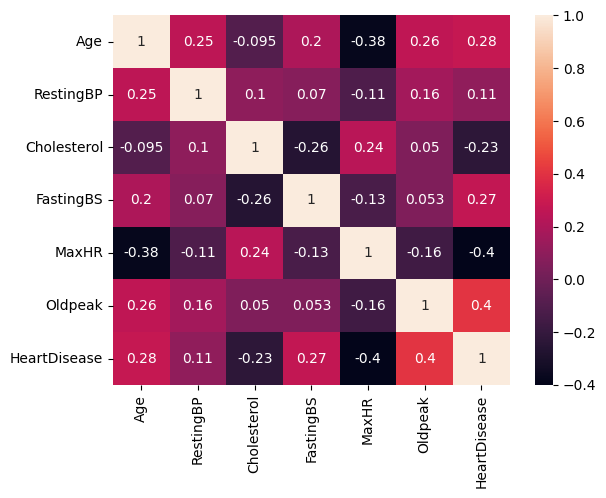

In [ ]:
cor=numurical_df.corr()
sns.heatmap(cor, annot=True)

<Axes: >

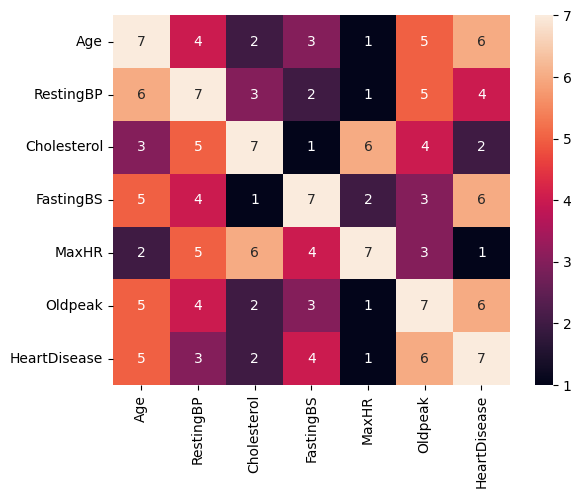

In [ ]:
sns.heatmap(cor.rank(axis='columns'), annot=True)

## Conclusion

# Preprocssing Data

In [ ]:
from sklearn.preprocessing import LabelEncoder
lab = LabelEncoder()

In [ ]:
cat_column = df.select_dtypes(include='object')
num_column = df.select_dtypes(exclude='object')

In [ ]:
print(cat_column.head())

  Sex ChestPainType RestingECG ExerciseAngina ST_Slope
0   M           ATA     Normal              N       Up
1   F           NAP     Normal              N     Flat
2   M           ATA         ST              N       Up
3   F           ASY     Normal              Y     Flat
4   M           NAP     Normal              N       Up


In [ ]:
for i in range(0, cat_column.shape[1]):
  cat_column.iloc[:, i]=lab.fit_transform(cat_column.iloc[:, i])

In [ ]:
cat_column.head()

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,1,1,1,0,2
1,0,2,1,0,1
2,1,1,2,0,2
3,0,0,1,1,1
4,1,2,1,0,2


In [ ]:
data = pd.concat([cat_column, num_column], axis=1)
# data = pd.concat([cat_column, num_column])

In [ ]:
data.head()

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
0,1,1,1,0,2,40,140,289,0,172,0.0,0
1,0,2,1,0,1,49,160,180,0,156,1.0,1
2,1,1,2,0,2,37,130,283,0,98,0.0,0
3,0,0,1,1,1,48,138,214,0,108,1.5,1
4,1,2,1,0,2,54,150,195,0,122,0.0,0


# Modeling

In [ ]:
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
x= data.drop(['HeartDisease'], axis=1)

y= data['HeartDisease']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y, train_size=.7)

In [ ]:
def all(model):
    model.fit(x_train, y_train)
    pre = model.predict(x_test)
    print(confusion_matrix(pre, y_test))
    print(classification_report(pre, y_test))

 **KNeighborsClassifier**

In [ ]:
model1 = KNeighborsClassifier()
all(model)

[[102  26]
 [ 20 128]]
              precision    recall  f1-score   support

           0       0.84      0.80      0.82       128
           1       0.83      0.86      0.85       148

    accuracy                           0.83       276
   macro avg       0.83      0.83      0.83       276
weighted avg       0.83      0.83      0.83       276



In [ ]:
model2 = DecisionTreeClassifier()
all(model2)

[[102  26]
 [ 20 128]]
              precision    recall  f1-score   support

           0       0.84      0.80      0.82       128
           1       0.83      0.86      0.85       148

    accuracy                           0.83       276
   macro avg       0.83      0.83      0.83       276
weighted avg       0.83      0.83      0.83       276



In [ ]:
model3 = GaussianNB()
all(model3)

[[107  19]
 [ 15 135]]
              precision    recall  f1-score   support

           0       0.88      0.85      0.86       126
           1       0.88      0.90      0.89       150

    accuracy                           0.88       276
   macro avg       0.88      0.87      0.88       276
weighted avg       0.88      0.88      0.88       276



In [ ]:
model4 = SVC()
all(model4)

[[ 91  39]
 [ 31 115]]
              precision    recall  f1-score   support

           0       0.75      0.70      0.72       130
           1       0.75      0.79      0.77       146

    accuracy                           0.75       276
   macro avg       0.75      0.74      0.74       276
weighted avg       0.75      0.75      0.75       276



In [ ]:
model5 = RandomForestClassifier()
all(model5)

[[102  14]
 [ 20 140]]
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       116
           1       0.91      0.88      0.89       160

    accuracy                           0.88       276
   macro avg       0.87      0.88      0.87       276
weighted avg       0.88      0.88      0.88       276



In [ ]:
model6 = GradientBoostingClassifier()
all(model6)

[[104  16]
 [ 18 138]]
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       120
           1       0.90      0.88      0.89       156

    accuracy                           0.88       276
   macro avg       0.87      0.88      0.87       276
weighted avg       0.88      0.88      0.88       276

